In [1]:
import os
import random
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid, save_image

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pizza.npy"
data_path = "pizza.npy"

if not os.path.exists(data_path):
    urllib.request.urlretrieve(url, data_path)

pizza_data = np.load(data_path)

print("Pizza dataset shape:", pizza_data.shape)
print("Pixel value range:", pizza_data.min(), pizza_data.max())

Pizza dataset shape: (130371, 784)
Pixel value range: 0 255


In [4]:
max_samples = 30000

pizza_data = pizza_data[:max_samples]

pizza_images = pizza_data.reshape(-1, 28, 28).astype(np.float32)

pizza_images = pizza_images / 255.0
pizza_images = pizza_images * 2.0 - 1.0

pizza_images = torch.tensor(pizza_images).unsqueeze(1)

print("Prepared pizza image tensor shape:", pizza_images.shape)

Prepared pizza image tensor shape: torch.Size([30000, 1, 28, 28])


In [8]:
def unnormalize_images(x):
    return (x + 1) / 2


def show_image_grid(images, title, nrow=8):
    images = unnormalize_images(images)
    grid = make_grid(images, nrow=nrow, padding=2)

    grid_np = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(7, 7))

    if grid_np.shape[-1] == 1:
        plt.imshow(grid_np.squeeze(-1), cmap="gray")
    else:
        plt.imshow(grid_np)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()

    plt.show()

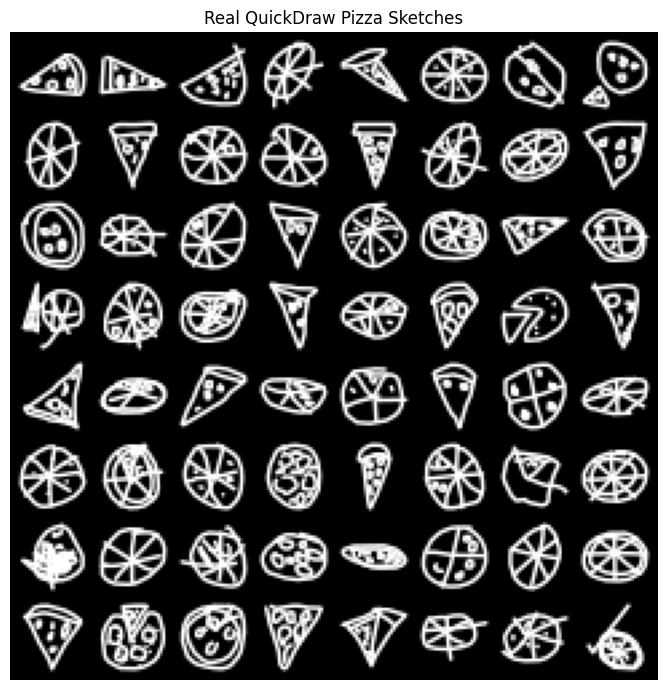

In [9]:
show_image_grid(
    pizza_images[:64],
    "Real QuickDraw Pizza Sketches",
    nrow=8
)

In [10]:
batch_size = 128

pizza_dataset = TensorDataset(pizza_images)

pizza_loader = DataLoader(
    pizza_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=True
)

In [12]:
class PizzaGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True),

            nn.Unflatten(1, (128, 7, 7)),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


class PizzaDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.2),

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.model(x)

In [16]:
def train_pizza_dcgan(
    generator,
    discriminator,
    train_loader,
    latent_dim=100,
    lr=0.0002,
    beta1=0.5,
    num_epochs=25,
    print_every=1
):
    generator = generator.to(device)
    discriminator = discriminator.to(device)

    loss_function = nn.BCEWithLogitsLoss()

    optimizer_g = torch.optim.Adam(
        generator.parameters(),
        lr=lr,
        betas=(beta1, 0.999)
    )

    optimizer_d = torch.optim.Adam(
        discriminator.parameters(),
        lr=lr,
        betas=(beta1, 0.999)
    )

    g_losses = []
    d_losses = []

    fixed_noise = torch.randn(64, latent_dim, device=device)

    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()

        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for batch in train_loader:
            real_images = batch[0].to(device)
            current_batch_size = real_images.size(0)

            real_targets = torch.ones(current_batch_size, 1, device=device)
            fake_targets = torch.zeros(current_batch_size, 1, device=device)

            noise = torch.randn(current_batch_size, latent_dim, device=device)
            fake_images = generator(noise)

            discriminator.zero_grad()

            real_outputs = discriminator(real_images)
            fake_outputs = discriminator(fake_images.detach())

            real_loss = loss_function(real_outputs, real_targets)
            fake_loss = loss_function(fake_outputs, fake_targets)
            d_loss = real_loss + fake_loss

            d_loss.backward()
            optimizer_d.step()

            noise = torch.randn(current_batch_size, latent_dim, device=device)
            fake_images = generator(noise)

            generator.zero_grad()

            fake_outputs = discriminator(fake_images)
            g_loss = loss_function(fake_outputs, real_targets)

            g_loss.backward()
            optimizer_g.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d_loss = epoch_d_loss / len(train_loader)
        avg_g_loss = epoch_g_loss / len(train_loader)

        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)

        if (epoch + 1) % print_every == 0:
            print(
                f"Epoch [{epoch + 1}/{num_epochs}] "
                f"Loss D: {avg_d_loss:.4f} | Loss G: {avg_g_loss:.4f}"
            )

        if (epoch + 1) % 5 == 0:
            generator.eval()

            with torch.no_grad():
                preview_images = generator(fixed_noise).cpu()

            show_image_grid(
                preview_images,
                f"Generated Pizza Sketches - Epoch {epoch + 1}",
                nrow=8
            )

    return generator, discriminator, g_losses, d_losses

In [20]:
latent_dim = 100

pizza_generator = PizzaGenerator(latent_dim=latent_dim)
pizza_discriminator = PizzaDiscriminator()

pizza_generator, pizza_discriminator, pizza_g_losses, pizza_d_losses = train_pizza_dcgan(
    generator=pizza_generator,
    discriminator=pizza_discriminator,
    train_loader=pizza_loader,
    latent_dim=latent_dim,
    lr=0.0002,
    beta1=0.5,
    num_epochs=40,
    print_every=1
)

Output hidden; open in https://colab.research.google.com to view.

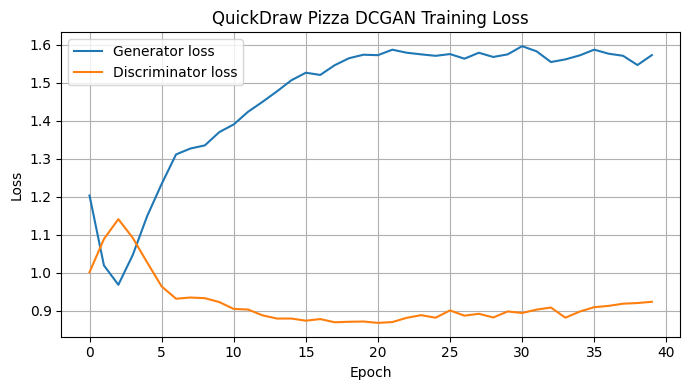

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(pizza_g_losses, label="Generator loss")
plt.plot(pizza_d_losses, label="Discriminator loss")
plt.title("QuickDraw Pizza DCGAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

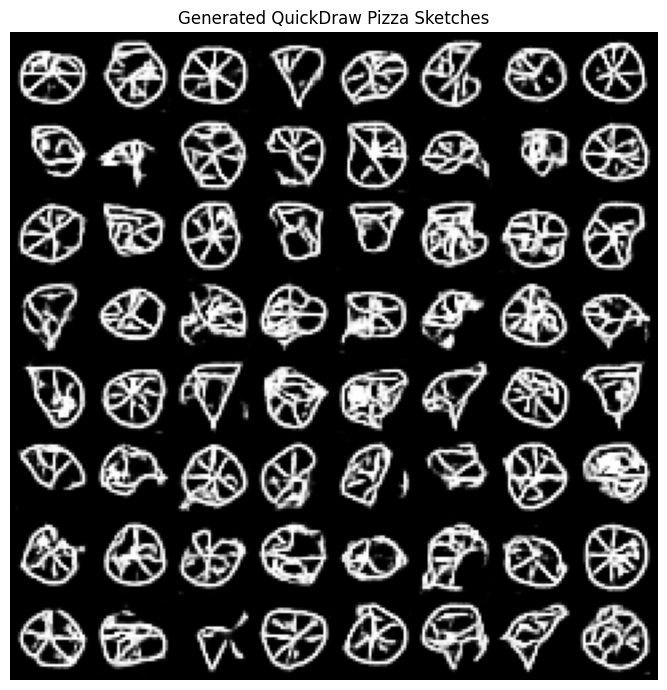

In [22]:
pizza_generator.eval()

with torch.no_grad():
    final_noise = torch.randn(64, latent_dim, device=device)
    fake_pizza_images = pizza_generator(final_noise).cpu()

show_image_grid(
    fake_pizza_images,
    "Generated QuickDraw Pizza Sketches",
    nrow=8
)